# Task 3: Predict age of a paddy plant based on its image

### Efficientnet-B0 PyTorch Implementation


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import hashlib
from collections import defaultdict
from PIL import Image

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# PyTorch Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

In [2]:
# Load the metadata CSV
meta_df = pd.read_csv("meta_train.csv")

# Display the first 5 rows
meta_df.head()


,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [3]:
# Check for nulls
print(meta_df.isnull().sum())

# Check for duplicate image IDs
print(f"Duplicates: {meta_df.duplicated('image_id').sum()}")

# Describe age distribution
meta_df['age'].describe()

image_id    0
label       0
variety     0
age         0
dtype: int64
Duplicates: 0


count    10407.000000
mean        64.043624
std          8.958830
min         45.000000
25%         60.000000
50%         67.000000
75%         70.000000
max         82.000000
Name: age, dtype: float64

In [4]:
# Drop rows with missing values (if any)
meta_df.dropna(subset=['age'], inplace=True)

# Drop duplicates just in case
meta_df.drop_duplicates(subset='image_id', inplace=True)


In [5]:
# Calc

def calculate_image_hash(image_path):
    """Calculate the hash of an image file."""
    hasher = hashlib.md5()
    with open(image_path, 'rb') as img_file:
        buf = img_file.read()
        hasher.update(buf)
    return hasher.hexdigest()

def find_duplicate_images(image_dir):
    """Find duplicate images in a directory with subdirectories."""
    hash_dict = defaultdict(list)

    # Traverse all subdirectories
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                file_path = os.path.join(root, file)
                img_hash = calculate_image_hash(file_path)
                hash_dict[img_hash].append(file_path)

    # Identify duplicates
    duplicates = {hash_val: paths for hash_val, paths in hash_dict.items() if len(paths) > 1}
    return duplicates

# Example usage
image_directory = "./train_images"  # Replace with your actual directory
duplicates = find_duplicate_images(image_directory)

if duplicates:
    print("Duplicate images found:")
    for hash_val, paths in duplicates.items():
        print(f"Hash: {hash_val}")
        for path in paths:
            print(f" - {path}")
else:
    print("No duplicate images found.")

Duplicate images found:
Hash: f09c3f34428337e9193c7df4c0a9369f
 - ./train_images\bacterial_leaf_blight\100133.jpg
 - ./train_images\bacterial_leaf_blight\103032.jpg
Hash: c1190cc23b0491e1099c8bc83958d575
 - ./train_images\bacterial_leaf_blight\100169.jpg
 - ./train_images\bacterial_leaf_blight\100513.jpg
Hash: 82c5a663a5f03a38a3893a5845e95ee2
 - ./train_images\bacterial_leaf_blight\100635.jpg
 - ./train_images\bacterial_leaf_blight\107812.jpg
Hash: ed6a8605beb94e5c03c1bde9187e9f6f
 - ./train_images\bacterial_leaf_blight\100998.jpg
 - ./train_images\bacterial_leaf_blight\106984.jpg
Hash: 1905f49eb2c964bd0515d3e235bb2171
 - ./train_images\bacterial_leaf_blight\101173.jpg
 - ./train_images\bacterial_leaf_blight\108353.jpg
Hash: 324354d461ed95144b403c52471a0634
 - ./train_images\bacterial_leaf_blight\102038.jpg
 - ./train_images\bacterial_leaf_blight\108125.jpg
Hash: 165d02db48857f69787d7b295d379ecd
 - ./train_images\bacterial_leaf_blight\102353.jpg
 - ./train_images\bacterial_leaf_blight\

In [6]:
# Remove duplicate images
dupes_to_remove = set()
for hash_val, paths in duplicates.items():
    # Keep first image, mark others for removal
    for path in paths[1:]:
        dupes_to_remove.add(path.split('\\')[-1])

# Remove duplicates from meta_df
meta_df = meta_df[~meta_df['image_id'].isin(dupes_to_remove)]
print(f"Removed {len(dupes_to_remove)} duplicates.")


Removed 74 duplicates.


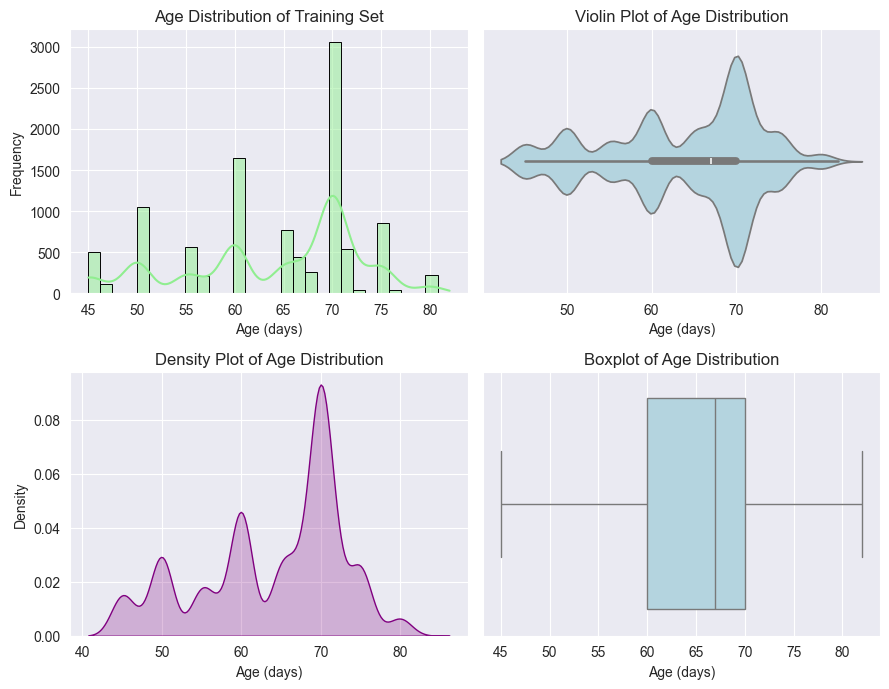

In [7]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Histogram
sns.histplot(meta_df['age'], bins=30, kde=True, color='lightgreen', edgecolor='black', ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution of Training Set")
axes[0, 0].set_xlabel("Age (days)")
axes[0, 0].set_ylabel("Frequency")

# Violin plot
sns.violinplot(x=meta_df['age'], color='lightblue', ax=axes[0, 1])
axes[0, 1].set_title("Violin Plot of Age Distribution")
axes[0, 1].set_xlabel("Age (days)")

# Density plot
sns.kdeplot(meta_df['age'], fill=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title("Density Plot of Age Distribution")
axes[1, 0].set_xlabel("Age (days)")
axes[1, 0].set_ylabel("Density")

# Boxplot
sns.boxplot(x=meta_df['age'], color='lightblue', ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of Age Distribution")
axes[1, 1].set_xlabel("Age (days)")

# Adjust layout
plt.tight_layout()
plt.show()

### Data Preprocessing
- In this section, we will preprocess the data. This includes:
  - Splitting the dataset into training and validation sets.
  - Normalizing the images.
  - Creating a custom dataset class to load images and labels.
    - The dataset class will handle the loading of images and their corresponding labels.
    - The images will be resized to a fixed size.
    - The labels will be converted to a tensor.
    - The dataset class will also apply any necessary transformations to the images.
    - The dataset class will return the images and labels in a format that can be used by the DataLoader.

In [8]:
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize with EfficientNet's mean and std
                         std =[0.229, 0.224, 0.225])  # These values are standard for torchvision models
])

In [9]:
class PaddyAgeDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, label_map=None, variety_map=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.label_map = label_map
        self.variety_map = variety_map

    def __len__(self):
        return len(self.df)

    @staticmethod
    def compute_grvi(tensor):
        r, g, b = tensor[0], tensor[1], tensor[2]
        grvi = (g - r) / (g + r + 1e-6)
        return grvi

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        image_path = os.path.join(self.image_dir, row['label'], row['image_id'])
        image = Image.open(image_path).convert("RGB")

        # Apply transform (should end at ToTensor, no normalization here)
        image = self.transform(image)  # shape [3, H, W]

        # Compute GRVI scalar (mean over image)
        grvi_map = self.compute_grvi(image)  # shape [H, W]

        grvi_mean = torch.tensor(grvi_map.mean().item(), dtype=torch.float32).unsqueeze(0)  # shape [1]

        # Normalize image AFTER computing GRVI
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        image = (image - mean) / std

        # Target: age
        label = torch.tensor(float(row['age']), dtype=torch.float32)

        # One-hot encode label and variety
        label_onehot = torch.zeros(len(self.label_map))
        variety_onehot = torch.zeros(len(self.variety_map))
        label_onehot[self.label_map[row["label"]]] = 1.0
        variety_onehot[self.variety_map[row["variety"]]] = 1.0

        return image, label, label_onehot, variety_onehot, grvi_mean


In [10]:
# Step 1: Train-Val Split
train_df, val_df = train_test_split(meta_df, test_size=0.2, random_state=42, stratify=meta_df['label'])

# Step 2: Create one-hot maps
label_map = {label: i for i, label in enumerate(meta_df['label'].unique())}
variety_map = {var: i for i, var in enumerate(meta_df['variety'].unique())}

# Step 3: Define Transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Step 4: Define Datasets
train_dataset = PaddyAgeDataset(train_df, image_directory,
                                transform=train_transforms,
                                label_map=label_map,
                                variety_map=variety_map)

val_dataset = PaddyAgeDataset(val_df, image_directory,
                              transform=val_transforms,
                              label_map=label_map,
                              variety_map=variety_map)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..1.9951199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179037..1.8683473].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179037..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179037..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179037..2.1519828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


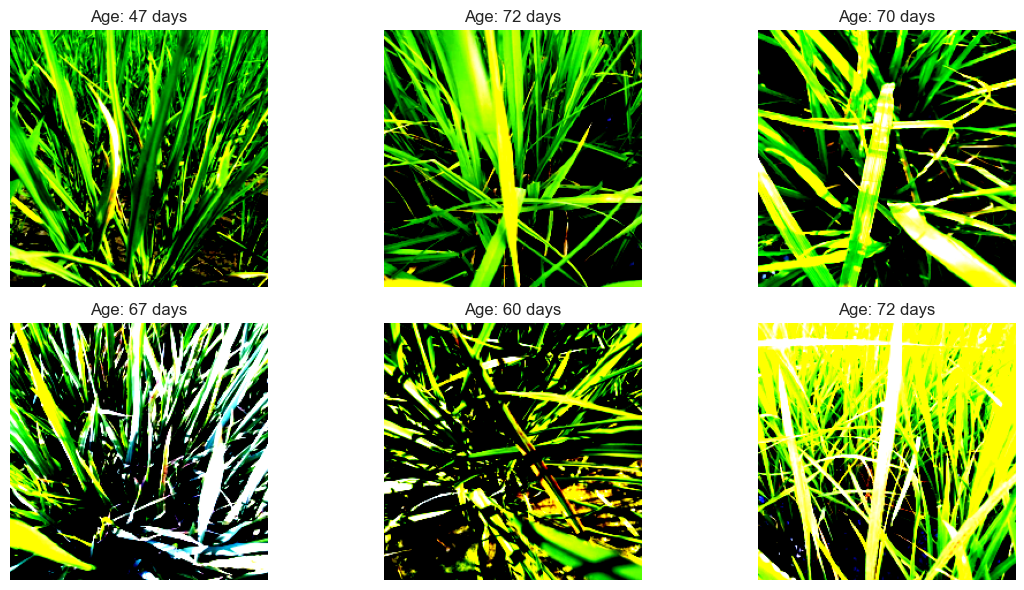

In [13]:
# Denormalization helper
def denormalize(img_tensor):
    # img_tensor: [4, H, W] → [R, G, B, GRVI]
    denorm = img_tensor.clone()

    # Only apply denormalization to the first 3 channels (RGB)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    denorm[:3] = denorm[:3] * std + mean  # only apply to RGB

    return denorm


# Get one batch from train_loader
images, ages, _, _, _ = next(iter(train_loader))  # Unpack only the first two values

# Plot 6 images from the batch
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Age: {ages[i]:.0f} days")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Model Building
- We will use EfficientNet-B0 as the base model.
- The model will be modified to include a regression head.

In [16]:
class AgeRegressor(nn.Module):
    def __init__(self, num_labels, num_varieties):
        super().__init__()
        # Load EfficientNet-B0 with no pretrained weights
        self.base = models.efficientnet_b0(weights=None)
        self.base.classifier = nn.Identity()  # Remove the 1000-class head
        self.base.features[0][0] = nn.Conv2d(4, 32, kernel_size=3, stride=2, padding=1, bias=False) # Change input channels to 4
        self.metadata_dim = num_labels + num_varieties + 1  # +1 for GRVI scalar

        # Add a regression head
        self.head = nn.Sequential(
            # Flatten the output from EfficientNet
            nn.Linear(1280 + self.metadata_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Add more layers for regression
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Final output layer
            nn.Linear(256, 1)
        )

    def forward(self, x, label_vec, variety_vec, grvi_scalar):
        features = self.base(x)
        meta = torch.cat([label_vec, variety_vec, grvi_scalar], dim=1)
        combined = torch.cat([features, meta], dim=1)
        return self.head(combined)

### Model Training Setup
- Setup the device (GPU or CPU) for training.
- Define the number of labels and varieties.
- Initialize the model with the required arguments.
- Define the loss function (Mean Squared Error for regression).
- Define the optimizer (Adam).
- Define the learning rate scheduler (ReduceLROnPlateau).
    - ReduceLROnPlateau is a learning rate scheduler that reduces the learning rate when a metric has stopped improving.
        - It is useful for training deep learning models.
        - The learning rate will be reduced if the validation loss does not improve for 3 epochs.
        - The minimum learning rate will be 1e-6.
        - This is to prevent the learning rate from becoming too small.
        - The learning rate will be reduced by a factor of 0.5.
        - This means that if the learning rate is 0.001, it will be reduced to 0.0005.
    - The learning rate will be reduced if the validation loss does not improve for 3 epochs.
    - The minimum learning rate will be 1e-6.
        - This is to prevent the learning rate from becoming too small.
        - The learning rate will be reduced by a factor of 0.5.
        - This means that if the learning rate is 0.001, it will be reduced to 0.0005.
        - The learning rate will be reduced if the validation loss does not improve for 3 epochs.

In [17]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the number of labels and varieties
num_labels = len(label_map)  # Number of unique labels
num_varieties = len(variety_map)  # Number of unique varieties

# Initialize the model with the required arguments
model = AgeRegressor(num_labels=num_labels, num_varieties=num_varieties).to(device)

# Mean Squared Error for regression
criterion = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Remove the verbose parameter
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)


### Training the Model
- The model will be trained using the Adam optimizer.
- The learning rate will be reduced if the validation loss does not improve for 3 epochs.
- The training will be stopped if the validation loss does not improve for 5 epochs (early stopping).
- The model will be trained for a maximum of 150 epochs.
- The training and validation loss will be recorded for each epoch.
- The model will be evaluated on the validation set after each epoch.
##### Training Loop Explanation:
- The training loop iterates over the number of epochs.
- For each epoch:
  - The model is set to training mode.
  - The training loss is calculated by iterating over the training data.
  - The model is set to evaluation mode.
  - The validation loss is calculated by iterating over the validation data.
  - The learning rate scheduler is stepped based on the validation loss.
  - Early stopping is implemented to prevent overfitting.
    - If the validation loss does not improve for a certain number of epochs, training is stopped.
    - The best model is saved based on the validation loss.
        - This is done by keeping track of the best validation loss and the corresponding model state.
                - The model state is saved using `torch.save(model.state_dict(), 'best_model.pth')`.

In [18]:
# Training Loop
# Define number of epochs
num_epochs = 150
# Record training loss and validation loss for plotting later
train_losses, val_losses = [], []
mse_vals, rmse_vals, r2_vals, mae_vals = [], [], [], []

best_val_loss = float('inf')  # Initialize best_val_loss
counter = 0  # Initialize counter
early_stopping_patience = 5  # Define patience threshold

print("Ping!")
print(f"Training started for {num_epochs} epochs.")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels, label_vecs, variety_vecs, grvi_scalars in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        label_vecs = label_vecs.to(device)
        variety_vecs = variety_vecs.to(device)
        grvi_scalars = grvi_scalars.to(device)

        optimizer.zero_grad()
        preds = model(images, label_vecs, variety_vecs, grvi_scalars)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    ## Validation Phase
    model.eval()
    val_preds, val_true = [], []
    val_loss = 0
    with torch.no_grad():
        for images, labels, label_vecs, variety_vecs, grvi_scalars  in val_loader:  # Unpack all required values
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)  # Ensure labels have shape [batch_size, 1]
            label_vecs = label_vecs.to(device)
            variety_vecs = variety_vecs.to(device)
            grvi_scalars = grvi_scalars.to(device)

            preds = model(images, label_vecs, variety_vecs, grvi_scalars)  # Pass all required inputs
            loss = criterion(preds, labels)  # Compute loss
            val_loss += loss.item()

            val_preds.extend(preds.cpu().squeeze().numpy())  # Convert preds to 1D array
            val_true.extend(labels.cpu().squeeze().numpy())

    val_loss = val_loss / len(val_loader)  # Calculate average validation loss
    val_losses.append(val_loss)
    # Step the scheduler using validation loss
    scheduler.step(val_loss)

    mse = mean_squared_error(val_true, val_preds)
    mse_vals.append(mse)
    rmse = root_mean_squared_error(val_true, val_preds)
    rmse_vals.append(rmse)
    r2 = r2_score(val_true, val_preds)
    r2_vals.append(r2)
    mae = mean_absolute_error(val_true, val_preds)
    mae_vals.append(mae)

    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | MAE: {mae:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss  # Update best validation loss
        counter = 0  # Reset counter
    else:
        counter += 1  # Increment counter for consecutive non-improvement epochs
        if counter >= early_stopping_patience:  # Check patience threshold
            print(f"Early stopping triggered at epoch {epoch + 1}.")
            break


Ping!
Training started for 150 epochs.
Current LR: 0.000100
Epoch 1/150 | Train Loss: 3935.4029 | Val Loss: 3736.9573
MSE: 3740.0390 | RMSE: 61.1559 | R2: -44.8286 | MAE: 60.5183
Current LR: 0.000100
Epoch 2/150 | Train Loss: 3525.7199 | Val Loss: 3328.5416
MSE: 3331.5077 | RMSE: 57.7192 | R2: -39.8226 | MAE: 57.0578
Current LR: 0.000100
Epoch 3/150 | Train Loss: 3092.3297 | Val Loss: 2823.4396
MSE: 2825.9818 | RMSE: 53.1600 | R2: -33.6282 | MAE: 52.3910
Current LR: 0.000100
Epoch 4/150 | Train Loss: 2587.3330 | Val Loss: 2359.2032
MSE: 2361.1640 | RMSE: 48.5918 | R2: -27.9325 | MAE: 47.4662
Current LR: 0.000100
Epoch 5/150 | Train Loss: 2107.8053 | Val Loss: 1902.4391
MSE: 1904.1975 | RMSE: 43.6371 | R2: -22.3331 | MAE: 42.4322
Current LR: 0.000100
Epoch 6/150 | Train Loss: 1651.9279 | Val Loss: 1502.0261
MSE: 1503.3806 | RMSE: 38.7735 | R2: -17.4217 | MAE: 37.6337
Current LR: 0.000100
Epoch 7/150 | Train Loss: 1262.7233 | Val Loss: 1280.8777
MSE: 1282.7213 | RMSE: 35.8151 | R2: -14.7

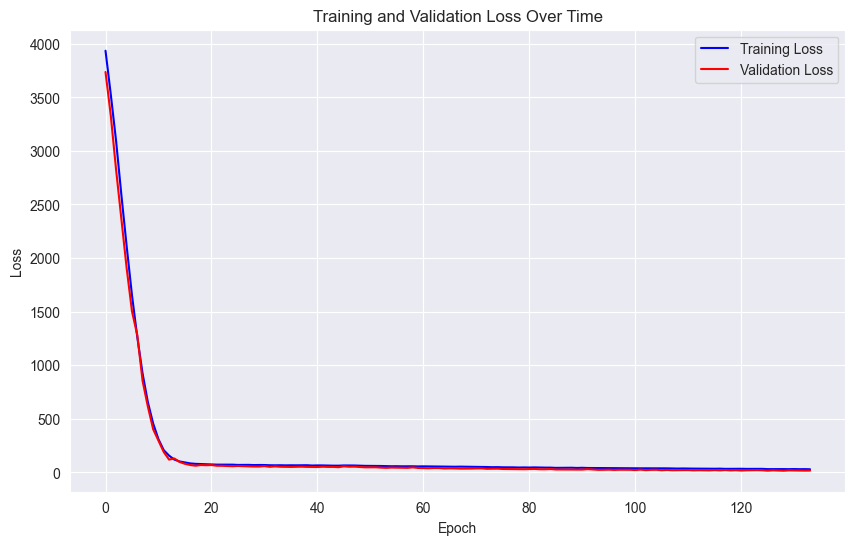

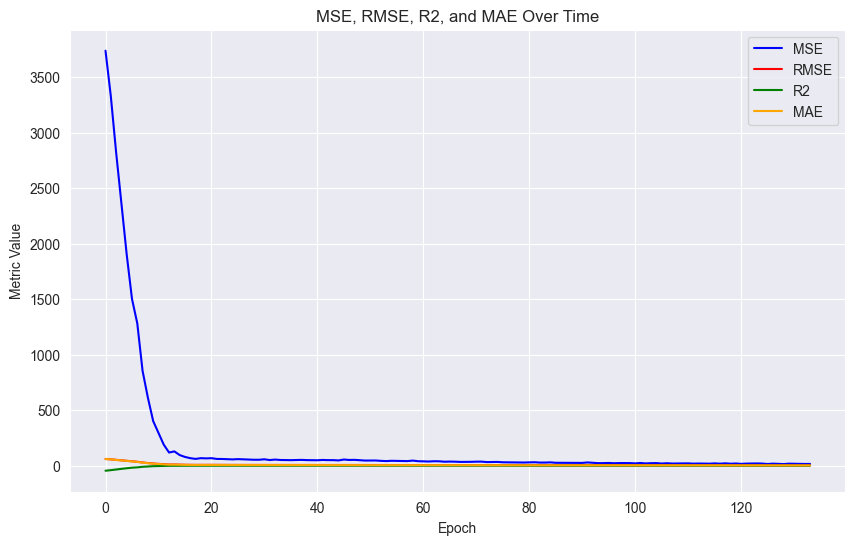

In [19]:
# Visualize Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Visualize MSE, RMSE, R2, and MAE
plt.figure(figsize=(10, 6))
plt.plot(mse_vals, label='MSE', color='blue')
plt.plot(rmse_vals, label='RMSE', color='red')
plt.plot(r2_vals, label='R2', color='green')
plt.plot(mae_vals, label='MAE', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('MSE, RMSE, R2, and MAE Over Time')
plt.legend()
plt.grid(True)
plt.show()



In [23]:
# Accuracy Quantifier
def age_accuracy(true_values, predictions, tolerance=1):
    """
    Calculate 'accuracy' for age predictions within a tolerance

    Args:
        true_values: Ground truth ages
        predictions: Predicted ages
        tolerance: Maximum allowed error in days

    Returns:
        Percentage of predictions within tolerance
    """
    absolute_errors = np.abs(np.array(true_values) - np.array(predictions))
    correct_predictions = (absolute_errors <= tolerance).sum()
    return correct_predictions / len(true_values) * 100

accuracy = age_accuracy(val_true, val_preds, tolerance=1)
accuracy = round(accuracy, 2)
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 24.09%


In [ ]:
#